# Model of Foucault Pendulum: Unlocking the Mysteries of Earth's Rotation   

Original submission, unedited. Preserved exactly as written for PHYS 305 final project, August to December 2024.

This notebook contains the code as originally submitted, including the typographical errors in the comments. See MEASUREMENT.md for how an 18.3% discrepancy turned out to be a measurement error, not a model error.

Error: zero
Latitude: 0 degrees
Theory Precession:0 Modeled Precession:0


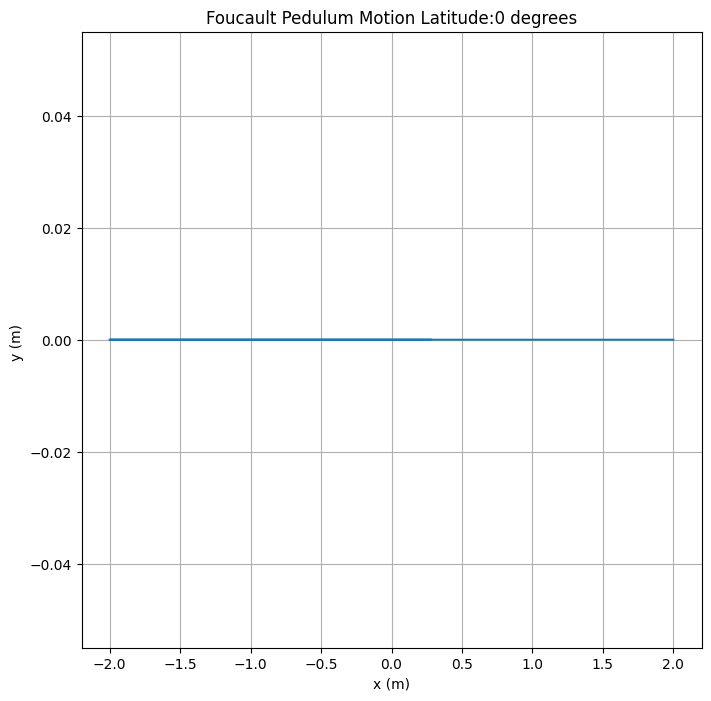

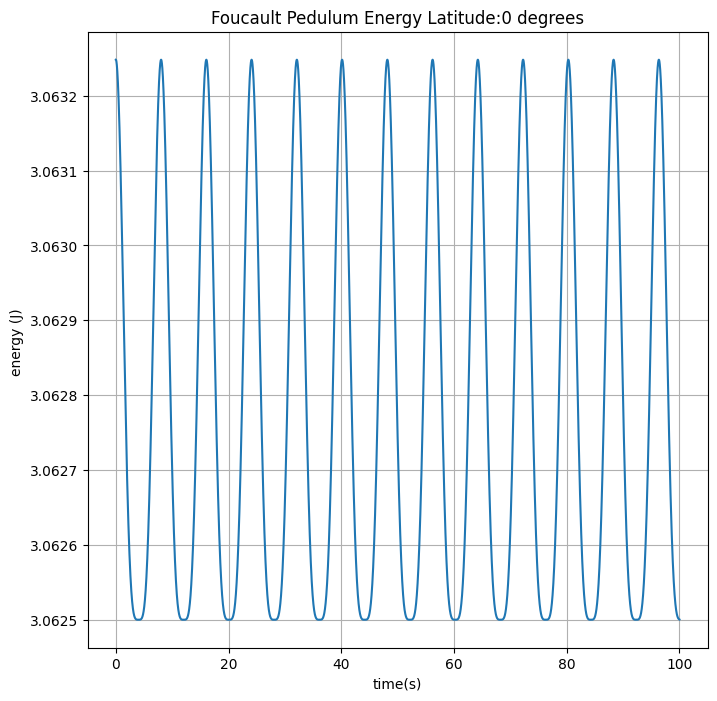

Error: 18.3%
Latitude: 36.2048 degrees
Theory Precession:4.3e-05 Modeled Precession:3.51e-05


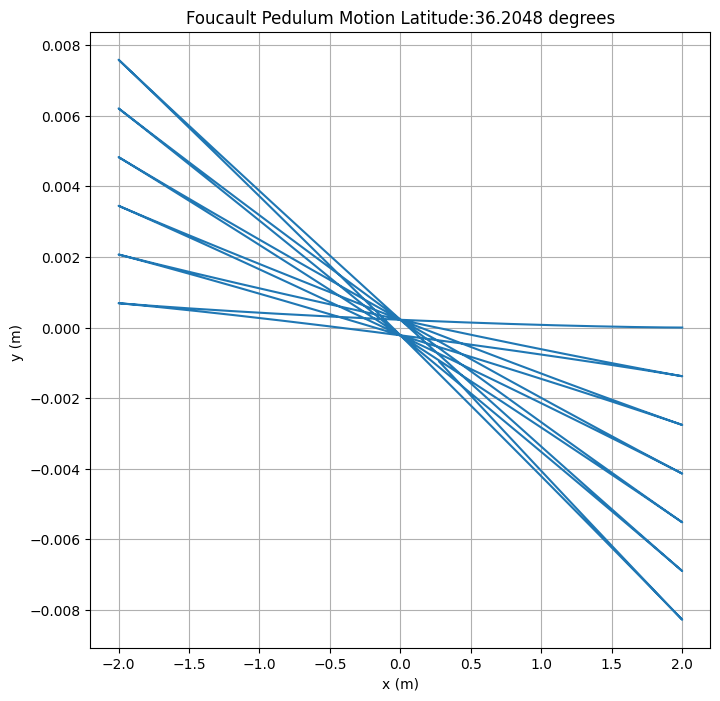

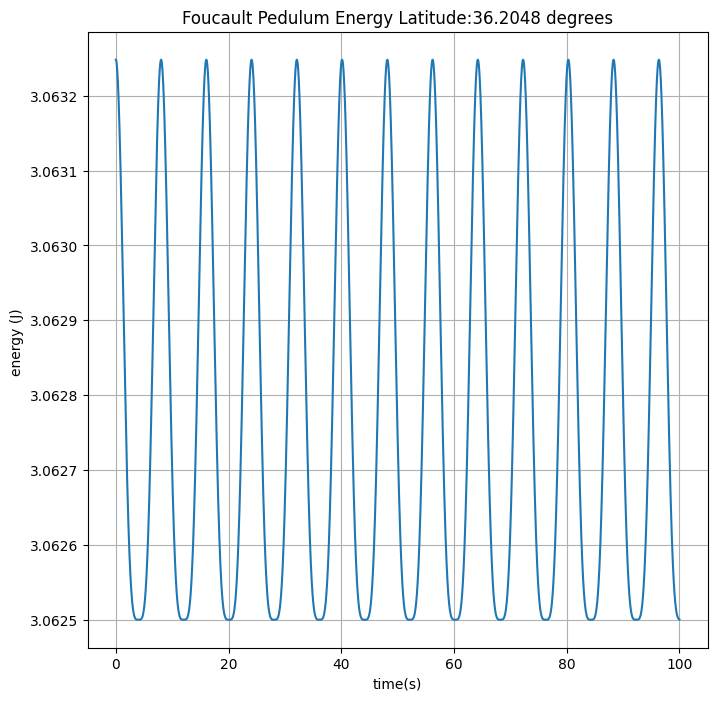

Error: 18.3%
Latitude: 40.7128 degrees
Theory Precession:4.74e-05 Modeled Precession:3.88e-05


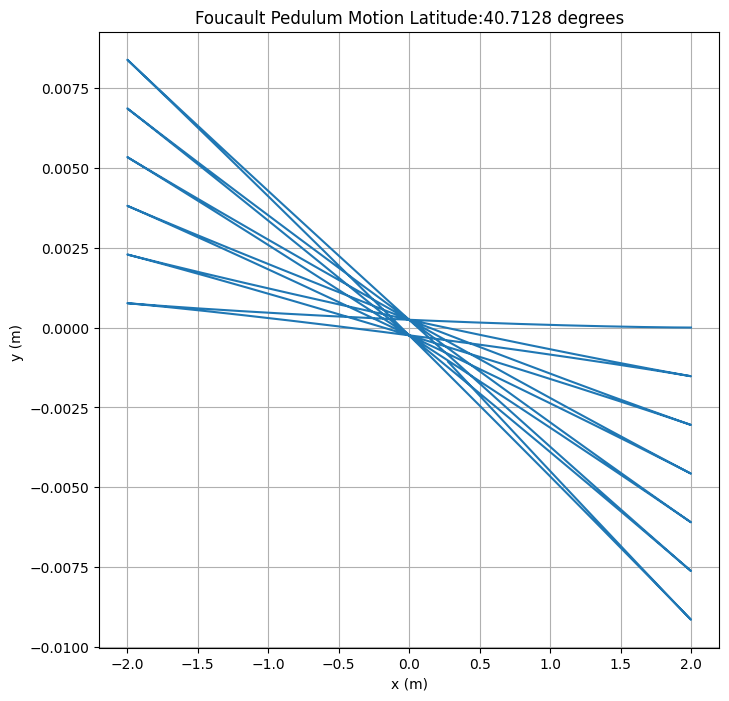

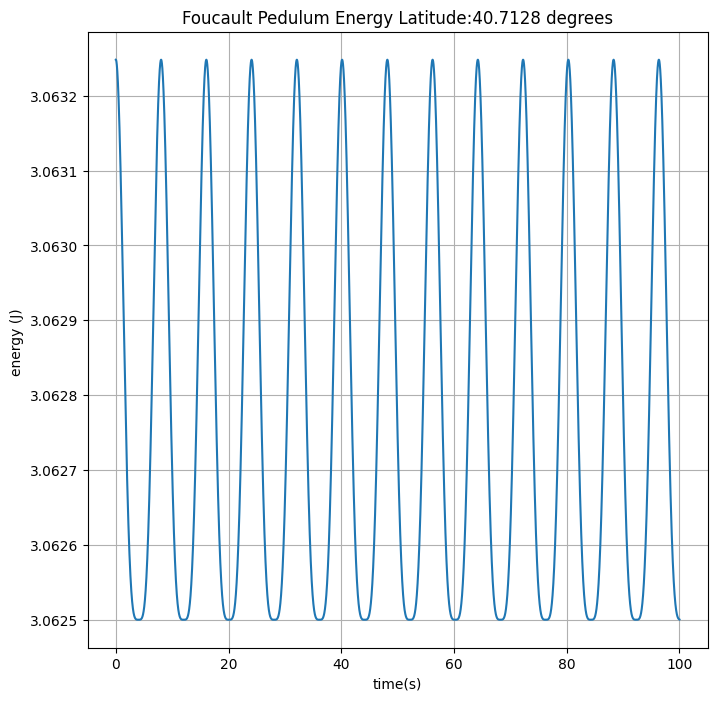

Error: 18.3%
Latitude: 82.8628 degrees
Theory Precession:7.22e-05 Modeled Precession:5.9e-05


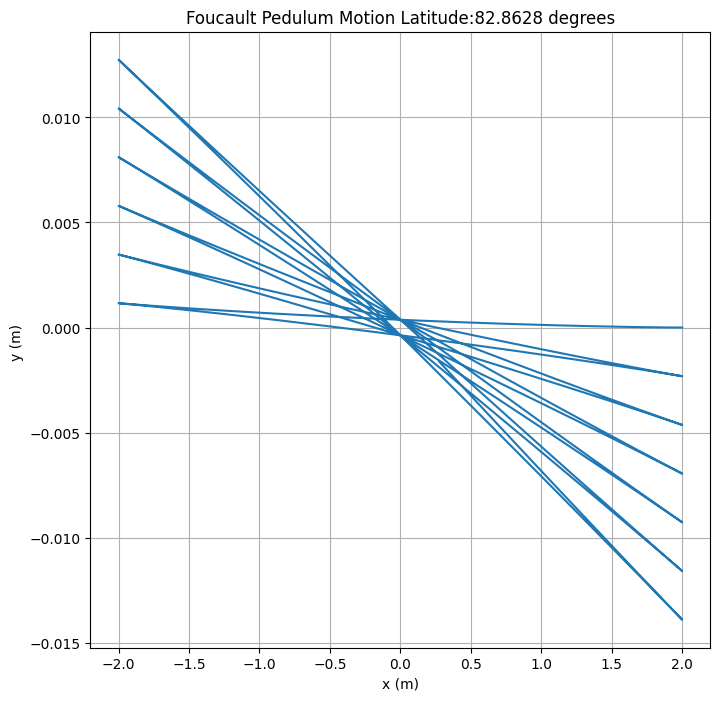

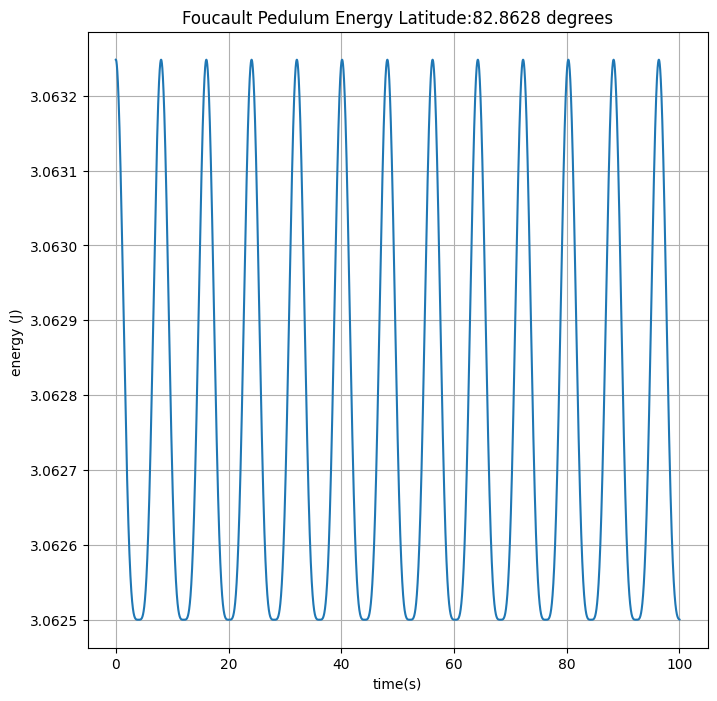

In [16]:
import numpy as np
import matplotlib.pyplot as plot

#I used different latitudes angles for phi to compare the precession rates to study earths rotation

# Japan- 36.2048, New York-40.7128, 0, Antarctica-82.8628
latitude = [0, 36.2048, 40.7128,82.8628]
#This function is used to solve the derivatives for the Foucault pendulum

def Foucault(dxdt,dydt,x,y,phi):
    #dxdt and dydt are the velocities, x and y are the positions, phi is the latitude
    dvx=2*w*np.sin(phi)*dydt-(g/L)*x
    dvy=-2*w*np.sin(phi)*dxdt-(g/L)*y
    return dvx, dvy
    
def fourthR_K(x0, y0, vx0, vy0, phi, T, dt):
    # function to use 4th order Runge-Kutta to model the motion of a Foucault pendulum
    #x0 and y0 is initial position, vx0 and vy0 is initial velocity, phi is the latitudes, T is the total time , dt is the time steps
    Num = int(T/dt)
    time = np.linspace(0, T, Num )
    x = np.zeros(Num )
    y = np.zeros(Num)
    dxdt = np.zeros(Num )
    dydt = np.zeros(Num )
    energy=np.zeros(Num)
    
    #initial conditiions
    x[0] = x0
    y[0] = y0
    dxdt [0] = vx0
    dydt [0] = vy0
    energy[0]=1/2*m*(dxdt[0]**2+dydt[0]**2)+m*g *(L-np.sqrt(L**2-x[0]**2-y[0]**2))
    # calculating using 4th order Runge-Kutta but first we need to define our system of equations for the problem
    
    for i in range(1, Num):
        # this is the first steep as we splitt it iinto four parts
        k1x = dxdt [i-1]
        k1y = dydt [i-1]
        k1vx = 2*w*np.sin(phi)*dydt[i-1]-(g/L)*x[i-1]
        k1vy=-2*w*np.sin(phi)*dxdt[i-1]-(g/L)*y[i-1]
        
        #2nd sttep out of four
        k2x = dxdt [i-1]+dt/2*(2*w*np.sin(phi)*dydt[i-1]-(g/L)*x[i-1])
        k2y = dydt[i-1]+dt/2*( -2*w*np.sin(phi)*dxdt[i-1]-(g/L)*y[i-1])
        k2vx = 2*w*np.sin(phi)*(dydt[i-1]+dt/2*k1vy)-(g/L)*(x[i-1]+dt/2*(dxdt [i-1] ))
        k2vy=-2*w*np.sin(phi)*(dxdt[i-1]+dt/2*k1vx)-(g/L)*(y[i-1]+dt/2*(dydt [i-1] ))
        
        # tthiird step out of ffouur
        k3x = dxdt [i-1]+dt/2*(2*w*np.sin(phi)*(dydt[i-1]+dt/2*k1vy)-(g/L)*(x[i-1]+dt/2*(dxdt [i-1] )))
        k3y = dydt[i-1]+dt/2*(-2*w*np.sin(phi)*(dxdt[i-1]+dt/2*k1vx)-(g/L)*(y[i-1]+dt/2*(dydt [i-1] )))
        k3vx = 2*w*np.sin(phi)*(dydt[i-1]+dt/2*k2vy)-(g/L)*(x[i-1]+dt/2*(dxdt [i-1]+dt/2*(2*w*np.sin(phi)*dydt[i-1]-(g/L)*x[i-1]) ))
        k3vy=-2*w*np.sin(phi)*(dxdt[i-1]+dt/2*k2vx)-(g/L)*(y[i-1]+dt/2*(dydt[i-1]+dt/2*( -2*w*np.sin(phi)*dxdt[i-1]-(g/L)*y[i-1]) ))
        
        #thiis will be the lasst part as we spllit the equattion into theee 4th order
        k4x = dxdt [i-1]+dt*(k3vx)
        k4y = dydt[i-1]+dt*(k3vy)
        k4vx = 2*w*np.sin(phi)*(dydt[i-1]+dt *k3vy)-(g/L)*(x[i-1]+dt *(k3x))
        k4vy= -2*w*np.sin(phi)*(dxdt[i-1]+dt *k3vx)-(g/L)*(y[i-1]+dt *(k3y))
        
        #now we can continue tto solve foor each systteem offf eequattiion witth 4th order runge-kutta
        x[i] = x[i-1] +dt/6*(k1x+2*k2x+2*k3x+k4x)
        y[i] = y[i-1] +dt/6*(k1y+2*k2y+2*k3y +k4y)
        dxdt [i] = dxdt [i-1] +dt/6*(k1vx+2*k2vx+2*k3vx+k4vx)
        dydt[i]= dydt [i-1] +dt/6*(k1vy+2*k2vy+2*k3vy+k4vy)
        
        #calculation of energyy
        energy[i]= 1/2*m*(dxdt[i] **2+dydt[i ]**2)+m*g *(L-np.sqrt(L**2-x[i ]**2-y[i ]**2))
    #retturn time and positions
    return time,x,y, energy
    
#values of the function to be used
T =100
dt = 0.0003
g = 9.8
w=2*np.pi/86400
L=64
m=10
x0=2
y0=0
vy0=0
vx0=0

# 4th order Runge-Kutta shown and modelling the various motions of foucaultt penddulum
phis=[np.radians(latitudes) for latitudes in latitude]
list1={}
list2={}
for i, phi in enumerate (phis):
    Time , x , y,energy = fourthR_K(x0, y0, vx0, vy0, phi, T, dt)
    list1[latitude[i]]=(Time,x,y,energy)
    
    # calculate precession to explain further on earth's rotation along with calculating error
    precession=abs(np.arctan (y [-1]/x[-1])/T)
    theory=w*np.sin(phi)
    list2[latitude[i]]=(precession,theory)
    if theory==0:
        error="zero"
    else:
        #error to check answers
        error=abs((precession-theory)/theory)*100
    print('Error:', error if error== 'zero' else'{:.1f}%'.format(error) )
    print('Latitude:',latitude[i],'degrees')
    print('Theory Precession:{:.3g}'.format(theory), 'Modeled Precession:{:.3g}'.format(precession) )
    
    # noow wee make the plott as a whole to see tthe behaviors
    plot.figure(figsize=(8,8))
    plot.plot(x,y )
    plot.title("Foucault Pedulum Motion Latitude:{} degrees".format(latitude [i]) )
    plot.xlabel('x (m)')
    plot.ylabel("y (m) ")
    plot.grid( )
    plot.show()
    
    #plot energy
    plot.figure(figsize=(8,8))
    plot.plot(Time, energy)
    plot.title("Foucault Pedulum Energy Latitude:{} degrees".format(latitude [i]) )
    plot.xlabel('time(s)')
    plot.ylabel("energy (J) ")
    plot.grid( )
    plot.show()